## <span style='background:rgb(0,255,255)' ><font color='black'>**Import OptiDamTool**</font></span>

In [2]:
import IPython
import OptiDamTool
import os

# mutiple output visibility from a single cell
IPython.InteractiveShell.ast_node_interactivity = 'all'

## <span style='background:rgb(0,255,255)' ><font color='black'>**Classes**</font></span>

In [9]:
watemsedem = OptiDamTool.WatemSedem()
network = OptiDamTool.Network()
analysis = OptiDamTool.Analysis()
visual = OptiDamTool.Visual()

## <span style='background:rgb(0,255,255)' ><font color='black'>**Folder Paths**</font></span>

In [4]:
current_dir = os.getcwd()

# download the 'data' folder from 'https://github.com/debpal/OptiDamTool/tree/main/tests/data' folder and adjust this path for your computer system.
data_folder = os.path.join(current_dir, 'tests', 'data')

# the output folder path needs to be adjusted according to the user's computer system
output_folder = os.path.join(os.path.dirname(current_dir), 'output_OptiDamTool')

## <span style='background:rgb(0,255,255)' ><font color='black'>**Methods of WatemSedem Class**</font></span>

### <span style='background:orange' ><font color='black'>**DEM to Stream Files**</font></span>

In [4]:
output = watemsedem.dem_to_stream(
    dem_file=os.path.join(data_folder, 'dem.tif'),
    flwacc_percent=2,
    folder_path=output_folder
)

# output

DEM reading time (seconds): 0.23
Pit filling and flow direction calculation time (seconds): 13.69
Slope calculation time (seconds): 2.14
Aspect calculation time (seconds): 1.09
Flow accumulation calculation time (seconds): 5.05
Stream calculation time (seconds): 1.91
Subbasin calculation time (seconds): 2.0
Total time (seconds): 26.27

Stream raster creation complete

Stream routing raster creation complete



### <span style='background:orange' ><font color='black'>**Model Region Extension**</font></span>

In [5]:
output = watemsedem.model_region_extension(
    dem_file=os.path.join(data_folder, 'dem.tif'),
    buffer_units=50,
    folder_path=output_folder
)

# output

### <span style='background:orange' ><font color='black'>**Raster Clipping by Bounding Box**</font></span>

In [6]:
output = watemsedem.raster_clipping_by_bounding_box(
    input_file=os.path.join(data_folder, 'R_clipped.tif'),
    shape_file=os.path.join(output_folder, 'region_buffer.shp'),
    output_file=os.path.join(output_folder, 'RUSLE_R_region.tif')
)

### <span style='background:orange' ><font color='black'>**Raster Reprojection, Clipping, and Resolution Rescaling**</font></span>

In [7]:
output = watemsedem.raster_reproject_clipping_rescaling(
    input_file=os.path.join(output_folder, 'RUSLE_R_region.tif'),
    resampling_method='bilinear',
    shape_file=os.path.join(output_folder, 'region.shp'),
    mask_file=os.path.join(output_folder, 'region.tif'),
    output_file=os.path.join(output_folder, 'RUSLE_R.tif')
)

### <span style='background:orange' ><font color='black'>**Constant Raster and NoData Replacement**</font></span>

In [8]:
output = watemsedem.raster_constant_extension(
    input_file=os.path.join(output_folder, 'region.tif'),
    constant_value=0.1694,
    region_file=os.path.join(output_folder, 'region.tif'),
    output_file=os.path.join(output_folder, 'RUSLE_K.tif'),
    dtype='float32'
)

### <span style='background:orange' ><font color='black'>**Multiplication of Soil Erodibility and Rainfall Erosivity Factors**</font></span>

In [9]:
output = watemsedem.rusle_kr(
    k_file=os.path.join(output_folder, 'RUSLE_K.tif'),
    r_file=os.path.join(output_folder, 'RUSLE_R.tif'),
    region_file=os.path.join(output_folder, 'region.tif'),
    output_file=os.path.join(output_folder, 'KR.tif'),
    k_multiplier=1000
)

### <span style='background:orange' ><font color='black'>**Esri Land Cover Raster Processing**</font></span>

In [10]:
output = watemsedem.land_cover_esri(
    lc_file=os.path.join(data_folder, 'land_cover_clipped.tif'),
    stream_file=os.path.join(output_folder, 'stream_lines.shp'),
    folder_path=output_folder
)

output

'Total agricultural lands identified: 1417'

### <span style='background:orange' ><font color='black'>**Land Management Factor**</font></span>

In [11]:
output = watemsedem.land_management_factor(
    lc_file=os.path.join(data_folder, 'land_cover_clipped.tif'),
    stream_file=os.path.join(output_folder, 'stream_lines.shp'),
    output_file=os.path.join(output_folder, 'RUSLE_C.tif')
)

# output

### <span style='background:orange' ><font color='black'>**Raster Spatial Extension**</font></span>

In [12]:
output = watemsedem.raster_extension(
    input_file=os.path.join(output_folder, 'stream_lines.tif'),
    fill_value=0,
    region_file=os.path.join(output_folder, 'region_buffer.tif'),
    output_file=os.path.join(output_folder, 'stream_buffer.tif')
)

### <span style='background:orange' ><font color='black'>**Raster Driver Conversion**</font></span>

In [13]:
file_dict = {
    'stream': os.path.join(output_folder, 'stream_buffer.tif')
}

output = watemsedem.raster_driver_to_rst(
    file_dict=file_dict,
    folder_path=output_folder
)

output

['stream.rst']

### <span style='background:orange' ><font color='black'>**Dam Controlled Upstream Drainage Polygons**</font></span>

In [14]:
output = watemsedem.dam_controlled_drainage_polygons(
    flwdir_file=os.path.join(output_folder, 'flwdir.tif'),
    location_file=os.path.join(output_folder, 'subbasin_drainage_points.shp'),
    location_col='ws_id',
    dam_list=[21, 22, 5, 31, 17, 24, 27, 2, 13, 1],
    folder_path=output_folder
)

# output

## <span style='background:rgb(0,255,255)' ><font color='black'>**Methods of Network Class**</font></span>

### <span style='background:orange' ><font color='black'>**Adjancent Downstream Dam Connectivity**</font></span>

In [15]:
output = network.connectivity_adjacent_downstream_dam(
    stream_file=os.path.join(output_folder, 'stream_lines.shp'),
    stream_col='ws_id',
    dam_list=[21, 22, 5, 31, 17, 24, 27, 2, 13, 1]
)

### <span style='background:orange' ><font color='black'>**Adjancent Upstream Dam Connectivity**</font></span>

In [16]:
output = network.connectivity_adjacent_upstream_dam(
    stream_file=os.path.join(output_folder, 'stream_lines.shp'),
    stream_col='ws_id',
    dam_list=[21, 22, 5, 31, 17, 24, 27, 2, 13, 1]
)

### <span style='background:orange' ><font color='black'>**Dam Controlled Upstream Drainage Area**</font></span>

In [17]:
output = network.controlled_drainage_area(
    stream_file=os.path.join(output_folder, 'stream_lines.shp'),
    stream_col='ws_id',
    dam_list=[21, 22, 5, 31, 17, 24, 27, 2, 13, 1]
)

### <span style='background:orange' ><font color='black'>**Sediment Inflow to Dam from Controlled Drainage Area**</font></span>

In [28]:
output = network.sediment_inflow_from_drainage_area(
    stream_file=os.path.join(output_folder, 'stream_with_sediment.geojson'),
    stream_col='ws_id',
    dam_list=[21, 22, 5, 31, 17, 24, 27, 2, 13, 1]
)

### <span style='background:orange' ><font color='black'>**Dam Upstream Summary Metrics**</font></span>

In [29]:
output = network.upstream_metrics_summary(
    stream_file=os.path.join(output_folder, 'stream_with_sediment.geojson'),
    stream_col='ws_id',
    dam_list=[21, 22, 5, 31, 17, 24, 27, 2, 13, 1],
    sort_dam=True
)

### <span style='background:orange' ><font color='black'>**Dam System Storage Dynamics Detailed Version**</font></span>

In [30]:
output = network.storage_dynamics_detailed(
    stream_file=os.path.join(output_folder, 'stream_with_sediment.geojson'),
    stream_col='ws_id',
    storage_dict={
        21: 1500000,
        5: 100000,
        24: 60000,
        27: 200000,
        33: 1000000,
    },
    year_limit=15,
    sediment_density=1300,
    trap_threshold=0.05,
    write_output=True,
    folder_path=output_folder
)

### <span style='background:orange' ><font color='black'>**Dam System Storage Dynamics Lite Version**</font></span>

In [6]:
output = network.storage_dynamics_lite(
    stream_file=os.path.join(output_folder, 'stream_with_sediment.geojson'),
    stream_col='ws_id',
    storage_dict={
        21: 1500000,
        5: 100000,
        24: 60000,
        27: 200000,
        33: 1000000,
    },
    year_limit=15,
    sediment_density=1300,
    trap_threshold=0.05,
    write_output=True,
    folder_path=output_folder
)

output

{'dam_initial_storage':    dam_id  storage_m3  storage_%   cum_m3
 0      21     1500000  52.447552  1500000
 1       5      100000   3.496503  1600000
 2      24       60000   2.097902  1660000
 3      27      200000   6.993007  1860000
 4      33     1000000  34.965035  2860000,
 'dam_lifespan':    dam_id  life_year
 0      21          7
 1       5          6
 2      24          4
 3      27          1
 4      33          8,
 'system_statistics':    start_year drainage_%  storage_%  sedtrap_% sedrelease_% dam_removed  \
 0           1      100.0      100.0   6.726402     1.707119          []   
 1           2      100.0  91.163521  19.348969    67.963192        [27]   
 2           3      100.0  85.481363   14.63525    84.964457          []   
 3           4      100.0  81.183469  13.797205    85.827129          []   
 4           5      100.0  75.108777  12.944463    86.704035        [24]   
 5           6      100.0  71.307412  11.501905     88.16908          []   
 6           7  

### <span style='background:orange' ><font color='black'>**Dam System Storage Dynamics with Location Point and Drainage Polygon Creation**</font></span>

In [7]:
output = network.storage_dynamics_and_drainage_scenarios(
    stream_file=os.path.join(output_folder, 'stream_with_sediment.geojson'),
    stream_col='ws_id',
    flwdir_file=os.path.join(output_folder, 'flwdir.tif'),
    storage_dict={
        21: 1500000,
        5: 100000,
        24: 60000,
        27: 200000,
        33: 1000000,
    },
    year_limit=15,
    sediment_density=1300,
    trap_threshold=0.05,
    folder_path=output_folder
)

# output

## <span style='background:rgb(0,255,255)' ><font color='black'>**Methods of Analysis Class**</font></span>

### <span style='background:orange' ><font color='black'>**Integrating Stream Information with Sediment Inflow**</font></span>

In [21]:
output = analysis.sediment_delivery_to_stream_json(
    info_file=os.path.join(output_folder, 'stream_information.json'),
    stream_col='ws_id',
    segsed_file=os.path.join(data_folder, 'Total sediment segments.txt'),
    cumsed_file=os.path.join(data_folder, 'Cumulative sediment segments.txt'),
    json_file=os.path.join(output_folder, 'stream_with_sediment.json')
)

### <span style='background:orange' ><font color='black'>**Stream Shapefile with Sediment Inflow Information**</font></span>

In [27]:
output = analysis.sediment_delivery_to_stream_geojson(
    stream_file=os.path.join(output_folder, 'stream_lines.shp'),
    sediment_file=os.path.join(output_folder, 'stream_with_sediment.json'),
    geojson_file=os.path.join(output_folder, 'stream_with_sediment.geojson')
)

### <span style='background:orange' ><font color='black'>**Summary of Total Sediment Dynamics**</font></span>

In [24]:
output = analysis.sediment_summary_dynamics_region(
    sediment_file=os.path.join(data_folder, 'Total sediment.txt'),
    summary_file=os.path.join(output_folder, 'summary.json'),
    output_file=os.path.join(output_folder, 'summary_total_sediment.json')
)

### <span style='background:orange' ><font color='black'>**Retrieve Raster Features**</font></span>

In [25]:
output = analysis.raster_features_retrieve(
    input_file=os.path.join(data_folder, 'WATEREROS_kg.rst'),
    crs_code=32638,
    output_file=os.path.join(output_folder, 'WATEREROS_ton.tif'),
    scale=.001
)

## <span style='background:rgb(0,255,255)' ><font color='black'>**Methods of Visual Class**</font></span>

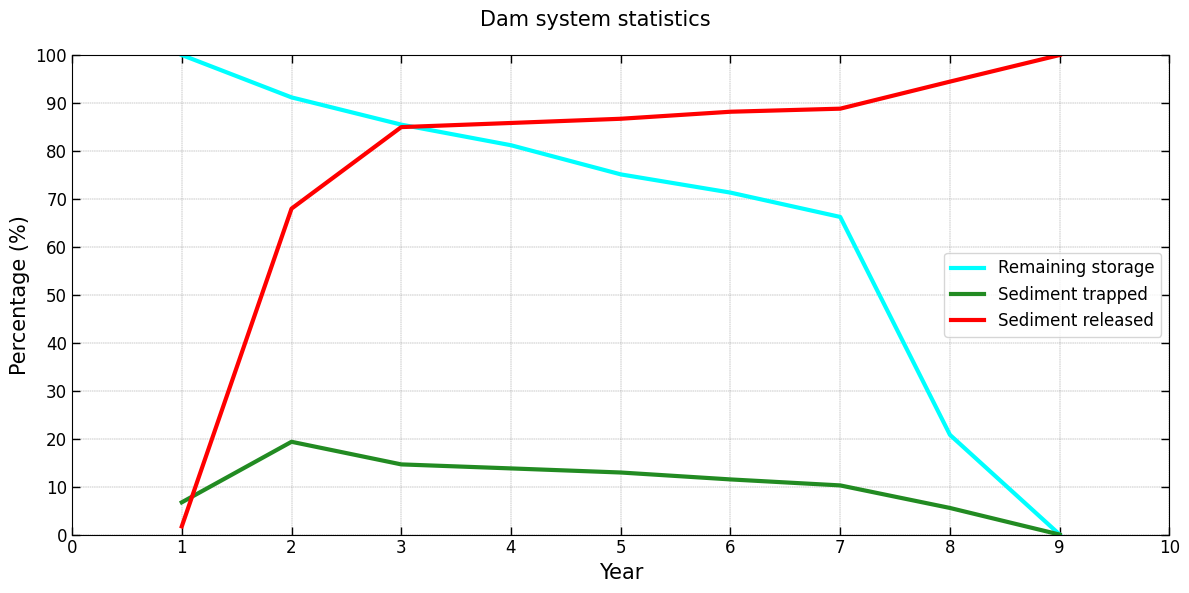

In [12]:
visual.system_statistics(
    json_file=os.path.join(output_folder, 'system_statistics.json'),
    figure_file=os.path.join(output_folder, 'system_statistics.png'),
    xtick_gap=1,
    gui_window=False
)